In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df = pd.read_csv("C:/Users/Arjun Waghmare/Downloads/house.csv")
df.head(4)

,Area,Bedrooms,Bathrooms,Price
0,1200,2,2,4500000
1,1500,3,2,5500000
2,1800,3,3,6500000
3,2000,4,3,7500000


In [4]:
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Area       20 non-null     int64
 1   Bedrooms   20 non-null     int64
 2   Bathrooms  20 non-null     int64
 3   Price      20 non-null     int64
dtypes: int64(4)
memory usage: 772.0 bytes


In [5]:
df.isnull().sum()

Area         0
Bedrooms     0
Bathrooms    0
Price        0
dtype: int64

In [6]:
df.fillna(df.mean(), inplace=True)

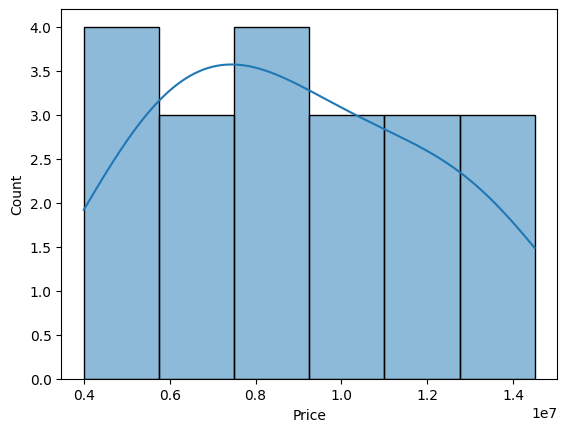

In [7]:
sns.histplot(df['Price'], kde=True)
plt.show()

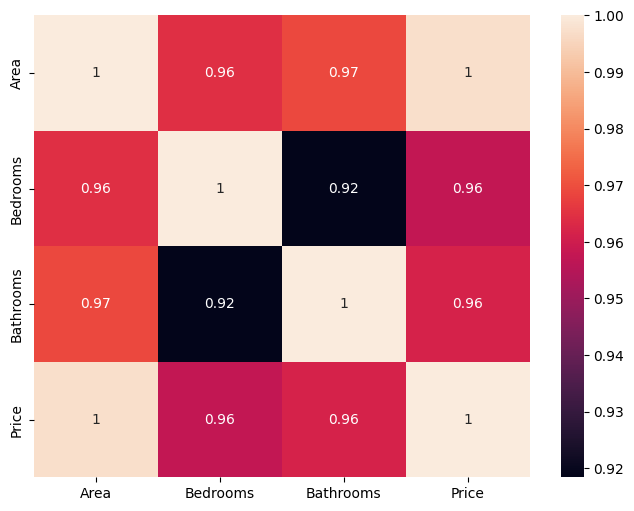

In [8]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [11]:
X = df[['Area','Bedrooms','Bathrooms']]
y = df['Price']

In [13]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
model = LinearRegression()

model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
y_pred = model.predict(X_test)

In [16]:
mse = mean_squared_error(y_test,y_pred)

print(mse)

98990505521.44354


In [17]:
r2 = r2_score(y_test,y_pred)

print(r2)

0.985151888175278


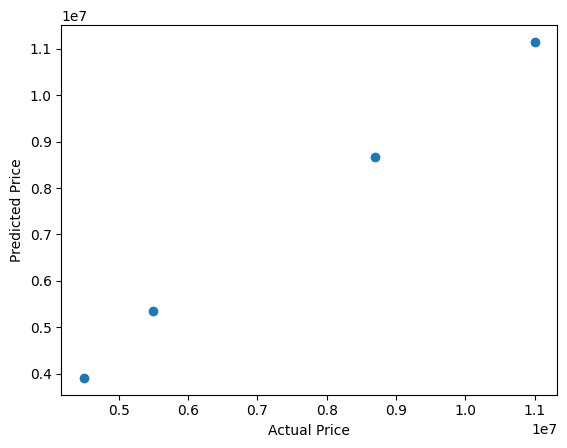

In [18]:
plt.scatter(y_test,y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.show()

In [19]:
new_house = [[2000,3,2]]

price = model.predict(new_house)

print(price)

[7953489.83970719]


c:\Users\Arjun Waghmare\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
